# Yelp 餐饮数据：简单分析与清洗

本 notebook 对 `data/kaggle/` 下 Yelp 学术数据集做概览、筛选（仅餐饮）与清洗，供后续商业餐饮智能分析使用。

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("../data/kaggle")
# 大表用采样避免内存爆掉；小表全量读取
print("数据目录:", DATA_DIR.resolve())
print("文件列表:", list(DATA_DIR.glob("*.json")))

数据目录: /Users/guyu/Desktop/ml final project/commercial-dining-intelligence/data/kaggle
文件列表: [PosixPath('../data/kaggle/yelp_academic_dataset_checkin.json'), PosixPath('../data/kaggle/yelp_academic_dataset_tip.json'), PosixPath('../data/kaggle/yelp_academic_dataset_review.json'), PosixPath('../data/kaggle/yelp_academic_dataset_business.json'), PosixPath('../data/kaggle/yelp_academic_dataset_user.json')]


In [2]:
# 1. Business 全量（约 15 万条）
df_business = pd.read_json(DATA_DIR / "yelp_academic_dataset_business.json", lines=True)
print("Business 形状:", df_business.shape)
print("字段:", df_business.columns.tolist())
df_business.head(3)

Business 形状: (150346, 14)
字段: ['business_id', 'name', 'address', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'stars', 'review_count', 'is_open', 'attributes', 'categories', 'hours']


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."


In [4]:
df_business["state"].value_counts()

state
PA     34039
FL     26330
TN     12056
IN     11247
MO     10913
LA      9924
AZ      9912
NJ      8536
NV      7715
AB      5573
CA      5203
ID      4467
DE      2265
IL      2145
TX         4
CO         3
WA         2
HI         2
MA         2
NC         1
UT         1
MT         1
MI         1
SD         1
XMS        1
VI         1
VT         1
Name: count, dtype: int64

In [3]:
# 2. Review 采样 50 万行（全量约 699 万，后续可按需全量跑）
df_review = pd.read_json(DATA_DIR / "yelp_academic_dataset_review.json", lines=True, nrows=500_000)
print("Review 形状 (采样):", df_review.shape)
print("字段:", df_review.columns.tolist())
df_review.head(2)

Review 形状 (采样): (500000, 9)
字段: ['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date']


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18


In [4]:
# 3. User 采样 20 万行（全量约 198 万）
df_user = pd.read_json(DATA_DIR / "yelp_academic_dataset_user.json", lines=True, nrows=200_000)
print("User 形状 (采样):", df_user.shape)
print("字段:", df_user.columns.tolist())
df_user.head(2)

User 形状 (采样): (200000, 22)
字段: ['user_id', 'name', 'review_count', 'yelping_since', 'useful', 'funny', 'cool', 'elite', 'friends', 'fans', 'average_stars', 'compliment_hot', 'compliment_more', 'compliment_profile', 'compliment_cute', 'compliment_list', 'compliment_note', 'compliment_plain', 'compliment_cool', 'compliment_funny', 'compliment_writer', 'compliment_photos']


,user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,"NSCy54eWehBJyZdG2iE84w, pe42u7DcCH2QmI81NX-8qA...",267,...,65,55,56,18,232,844,467,467,239,180
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...","ueRPE0CX75ePGMqOFVj6IQ, 52oH4DrRvzzl8wh5UXyU0A...",3138,...,264,184,157,251,1847,7054,3131,3131,1521,1946


In [5]:
# 4. Checkin 全量（约 13 万）
df_checkin = pd.read_json(DATA_DIR / "yelp_academic_dataset_checkin.json", lines=True)
# 5. Tip 采样 20 万行（全量约 90 万）
df_tip = pd.read_json(DATA_DIR / "yelp_academic_dataset_tip.json", lines=True, nrows=200_000)
print("Checkin 形状:", df_checkin.shape, "| Tip 形状 (采样):", df_tip.shape)
df_checkin.head(2)

Checkin 形状: (131930, 2) | Tip 形状 (采样): (200000, 5)


,business_id,date
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020..."
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011..."


## 简单分析：缺失与分布

- **Business**：`categories` 为字符串（多类别逗号分隔），`attributes`/`hours` 可能为 dict 或 null。  
- **Review**：`text` 可能为空或很长，`stars` 1–5。  
- 先看缺失与数值分布，再只保留**餐饮相关**商家。

In [6]:
# 缺失值概览
print("=== Business 缺失 ===")
print(df_business.isnull().sum())
print("\n=== Review 缺失 ===")
print(df_review.isnull().sum())
print("\n=== User 缺失 ===")
print(df_user.isnull().sum())

=== Business 缺失 ===
business_id         0
name                0
address             0
city                0
state               0
postal_code         0
latitude            0
longitude           0
stars               0
review_count        0
is_open             0
attributes      13744
categories        103
hours           23223
dtype: int64

=== Review 缺失 ===
review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64

=== User 缺失 ===
user_id               0
name                  0
review_count          0
yelping_since         0
useful                0
funny                 0
cool                  0
elite                 0
friends               0
fans                  0
average_stars         0
compliment_hot        0
compliment_more       0
compliment_profile    0
compliment_cute       0
compliment_list       0
compliment_note       0
compliment_plain      0
compliment_cool       0
c

In [7]:
# 数值型关键字段分布
print("Business: stars, review_count, is_open")
print(df_business[["stars", "review_count", "is_open"]].describe())
print("\nReview: stars")
print(df_review["stars"].value_counts().sort_index())

Business: stars, review_count, is_open
               stars   review_count       is_open
count  150346.000000  150346.000000  150346.00000
mean        3.596724      44.866561       0.79615
std         0.974421     121.120136       0.40286
min         1.000000       5.000000       0.00000
25%         3.000000       8.000000       1.00000
50%         3.500000      15.000000       1.00000
75%         4.500000      37.000000       1.00000
max         5.000000    7568.000000       1.00000

Review: stars
stars
1     65233
2     38856
3     52589
4    114005
5    229317
Name: count, dtype: int64


In [8]:
# 餐饮筛选：categories 含 Restaurants 或 Food
def is_dining(cats):
    if pd.isna(cats) or not isinstance(cats, str):
        return False
    c = cats.lower()
    return "restaurant" in c or "food" in c

mask_dining = df_business["categories"].apply(is_dining)
df_business_dining = df_business[mask_dining].copy()
print(f"餐饮商家数: {df_business_dining.shape[0]} / {len(df_business)}")
df_business_dining.head(3)

餐饮商家数: 64629 / 150346


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,1,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '..."


In [9]:
# 只保留餐饮商家的 review / checkin / tip（与 business 对齐）
bid_dining = set(df_business_dining["business_id"])
df_review_dining = df_review[df_review["business_id"].isin(bid_dining)].copy()
df_checkin_dining = df_checkin[df_checkin["business_id"].isin(bid_dining)].copy()
df_tip_dining = df_tip[df_tip["business_id"].isin(bid_dining)].copy()
print("筛选后: review", df_review_dining.shape[0], "checkin", df_checkin_dining.shape[0], "tip", df_tip_dining.shape[0])

筛选后: review 377678 checkin 63307 tip 157110


## 数据清洗

- **去重**：按主键去重（business_id, review_id 等）。  
- **缺失**：关键字段缺失可删行或填默认值；`categories` 缺失的 business 已在上一步筛掉。  
- **类型**：`date` 转 datetime；`stars` 等保持数值。  
- **异常**：如 `review_count`/`stars` 为负或超出范围可截断或丢弃。  
- **评论文本**：可选做空白/过长截断，此处仅做简单检查。

In [10]:
# 按主键去重
def dedup(df, subset):
    before = len(df)
    df.drop_duplicates(subset=subset, inplace=True)
    return before, len(df)

b_before, b_after = dedup(df_business_dining, ["business_id"])
r_before, r_after = dedup(df_review_dining, ["review_id"])
c_before, c_after = dedup(df_checkin_dining, ["business_id", "date"])
t_before, t_after = dedup(df_tip_dining, ["user_id", "business_id", "date"])
print("business_dining:", b_before, "->", b_after)
print("review_dining:", r_before, "->", r_after)
print("checkin_dining:", c_before, "->", c_after)
print("tip_dining:", t_before, "->", t_after)

business_dining: 64629 -> 64629
review_dining: 377678 -> 377678
checkin_dining: 63307 -> 63307
tip_dining: 157110 -> 157100


In [11]:
# 缺失与异常值处理
# Business: 丢弃关键字段缺失的行（若需保留可改为填充）
df_business_dining = df_business_dining.dropna(subset=["name", "city", "state"])
# stars 限制在 1-5，review_count >= 0
df_business_dining = df_business_dining[
    (df_business_dining["stars"] >= 1) & (df_business_dining["stars"] <= 5) &
    (df_business_dining["review_count"] >= 0)
]
# Review: 丢弃无文本或 stars 异常的
df_review_dining = df_review_dining.dropna(subset=["text"])
df_review_dining = df_review_dining[
    (df_review_dining["stars"] >= 1) & (df_review_dining["stars"] <= 5)
]
# 日期转 datetime
df_review_dining["date"] = pd.to_datetime(df_review_dining["date"], errors="coerce")
df_tip_dining["date"] = pd.to_datetime(df_tip_dining["date"], errors="coerce")
df_review_dining = df_review_dining.dropna(subset=["date"])
print("清洗后 business_dining:", len(df_business_dining), "review_dining:", len(df_review_dining))

清洗后 business_dining: 64629 review_dining: 377678


In [12]:
# 评论文本简单检查：空串或过短可标记（此处仅统计）
text_len = df_review_dining["text"].str.len()
print("评论长度: min={}, max={}, median={}".format(text_len.min(), text_len.max(), text_len.median()))
print("空串数量:", (df_review_dining["text"].str.strip() == "").sum())

评论长度: min=1, max=5000, median=382.0
空串数量: 0


In [13]:
# 保存清洗后的餐饮数据（可选：写到 data 目录下 csv 或 parquet）
OUT_DIR = Path("../data/cleaned")
OUT_DIR.mkdir(parents=True, exist_ok=True)
df_business_dining.to_csv(OUT_DIR / "business_dining.csv", index=False)
df_review_dining.to_csv(OUT_DIR / "review_dining.csv", index=False)
df_checkin_dining.to_csv(OUT_DIR / "checkin_dining.csv", index=False)
df_tip_dining.to_csv(OUT_DIR / "tip_dining.csv", index=False)
print("已保存到", OUT_DIR.resolve())
list(OUT_DIR.iterdir())

已保存到 /Users/guyu/Desktop/ml final project/commercial-dining-intelligence/data/cleaned


[PosixPath('../data/cleaned/checkin_dining.csv'),
 PosixPath('../data/cleaned/business_dining.csv'),
 PosixPath('../data/cleaned/review_dining.csv'),
 PosixPath('../data/cleaned/tip_dining.csv')]

## 小结

- **数据源**：Yelp 学术集 business / review / user / checkin / tip，其中 review 与 user 体量大，本 notebook 用采样便于快速跑通。  
- **筛选**：仅保留 `categories` 含 Restaurants 或 Food 的商家，并只保留这些商家的 review / checkin / tip。  
- **清洗**：去重、关键字段缺失删除、stars/review_count 范围限制、日期转 datetime、评论文本非空。  
- **输出**：清洗后的表保存到 `data/cleaned/`（business_dining, review_dining, checkin_dining, tip_dining）。  

若需全量处理，去掉 `read_json(..., nrows=...)` 并考虑分块读取或更大内存。

---
# 简单模型：预测餐厅评分（stars）

用**商家自身特征**（评论数、是否营业、州、经纬度、类别数等）预测餐厅的 **stars**（1–5 星），作为回归任务。采用线性回归 + 随机森林对比。

In [18]:
# 若前面已运行可直接用 df_business_dining，否则从清洗结果读取
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

OUT_DIR = Path("../data/cleaned")
if "df_business_dining" not in dir() or df_business_dining is None:
    df_biz = pd.read_csv(OUT_DIR / "business_dining.csv")
else:
    df_biz = df_business_dining.copy()
print("样本数:", len(df_biz), "| 目标 stars 分布:")
print(df_biz["stars"].value_counts().sort_index())

样本数: 64629 | 目标 stars 分布:
stars
1.0      316
1.5     1803
2.0     3732
2.5     5927
3.0     9048
3.5    13752
4.0    16050
4.5    11222
5.0     2779
Name: count, dtype: int64


In [19]:
# 特征工程：数值特征 + 类别编码
df_biz = df_biz.dropna(subset=["latitude", "longitude", "review_count", "state"])
df_biz["n_categories"] = df_biz["categories"].fillna("").str.split(",").str.len()
df_biz["has_hours"] = df_biz["hours"].notna().astype(int)
df_biz["has_attributes"] = df_biz["attributes"].notna().astype(int)

num_cols = ["review_count", "latitude", "longitude", "is_open", "n_categories", "has_hours", "has_attributes"]
# state 转 one-hot（只保留高频州，其余归为 Other）
state_counts = df_biz["state"].value_counts()
top_states = state_counts.head(12).index.tolist()
df_biz["state_grp"] = df_biz["state"].where(df_biz["state"].isin(top_states), "Other")
state_dummies = pd.get_dummies(df_biz["state_grp"], prefix="state")

X_num = df_biz[num_cols].astype(float)
X = pd.concat([X_num.reset_index(drop=True), state_dummies.reset_index(drop=True)], axis=1)
y = df_biz["stars"].values
feature_names = X.columns.tolist()
print("特征数:", X.shape[1], "| 特征名:", feature_names[:5], "...")
X.head(3)

特征数: 20 | 特征名: ['review_count', 'latitude', 'longitude', 'is_open', 'n_categories'] ...


,review_count,latitude,longitude,is_open,n_categories,has_hours,has_attributes,state_AB,state_AZ,state_CA,state_FL,state_ID,state_IN,state_LA,state_MO,state_NJ,state_NV,state_Other,state_PA,state_TN
0,80.0,39.955505,-75.155564,1.0,5.0,1.0,1.0,False,False,False,False,False,False,False,False,False,False,False,True,False
1,13.0,40.338183,-75.471659,1.0,3.0,1.0,1.0,False,False,False,False,False,False,False,False,False,False,False,True,False
2,6.0,36.269593,-87.058943,1.0,6.0,1.0,1.0,False,False,False,False,False,False,False,False,False,False,False,False,True


In [20]:
# 划分训练/测试集，标准化数值部分后训练（保留 test_idx 便于后续展示预测 vs 实际）
train_idx, test_idx = train_test_split(np.arange(len(X)), test_size=0.2, random_state=42)
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
scaler = StandardScaler()
# 只对数值列标准化（state one-hot 保持 0/1）
num_idx = [i for i, c in enumerate(X.columns) if c in num_cols]
X_train_std = X_train.copy()
X_test_std = X_test.copy()
X_train_std.iloc[:, num_idx] = scaler.fit_transform(X_train.iloc[:, num_idx])
X_test_std.iloc[:, num_idx] = scaler.transform(X_test.iloc[:, num_idx])

models = {
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
}
results = []
for name, model in models.items():
    model.fit(X_train_std, y_train)
    y_pred = model.predict(X_test_std)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({"model": name, "RMSE": rmse, "MAE": mae, "R2": r2})
    print(f"{name}: RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")
pd.DataFrame(results)

Ridge: RMSE=0.8442, MAE=0.6739, R²=0.0256
RandomForest: RMSE=0.8190, MAE=0.6535, R²=0.0829


,model,RMSE,MAE,R2
0,Ridge,0.844190,0.673861,0.025607
1,RandomForest,0.819006,0.653504,0.082876


In [21]:
# 准确性：回归用 RMSE/MAE；再按「四舍五入到整星」算准确率，以及「误差≤0.5星」比例
y_pred_rf = models["RandomForest"].predict(X_test_std)
pred_rounded = np.round(y_pred_rf).clip(1, 5)
acc_exact = (np.round(y_test) == pred_rounded).mean()
acc_within_half = (np.abs(y_test - y_pred_rf) <= 0.5).mean()
print("Random Forest 测试集:")
print(f"  整星预测准确率 (pred 四舍五入): {acc_exact:.2%}")
print(f"  误差 ≤0.5 星比例: {acc_within_half:.2%}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}  MAE: {mean_absolute_error(y_test, y_pred_rf):.4f}")

Random Forest 测试集:
  整星预测准确率 (pred 四舍五入): 49.77%
  误差 ≤0.5 星比例: 46.36%
  RMSE: 0.8190  MAE: 0.6535


In [22]:
# 10 条：预测 vs 实际（带餐厅名）
df_compare = df_biz.iloc[test_idx][["name", "city", "state"]].copy()
df_compare = df_compare.reset_index(drop=True)
df_compare["actual"] = y_test
df_compare["predicted"] = np.round(y_pred_rf, 2)
df_compare["error"] = np.round(df_compare["predicted"] - df_compare["actual"], 2)
df_compare.head(10)

,name,city,state,actual,predicted,error
0,The Gables At Chadds Ford,Chadds Ford,PA,3.0,3.83,0.83
1,Kahve Coffee,Boise,ID,5.0,3.67,-1.33
2,The Brewhouse,Wesley Chapel,FL,2.0,3.31,1.31
3,Papa Murphy's,Meridian,ID,3.0,3.53,0.53
4,Whitts Barbecue,Springfield,TN,2.0,3.39,1.39
5,Ramada,Edmonton,AB,3.0,3.52,0.52
6,Taco Bell,Tucson,AZ,2.0,3.14,1.14
7,Acropolis Greek Taverna,Tampa,FL,4.0,3.99,-0.01
8,Walgreens,Fenton,MO,1.5,3.11,1.61
9,China Star,Tampa,FL,4.0,3.19,-0.81


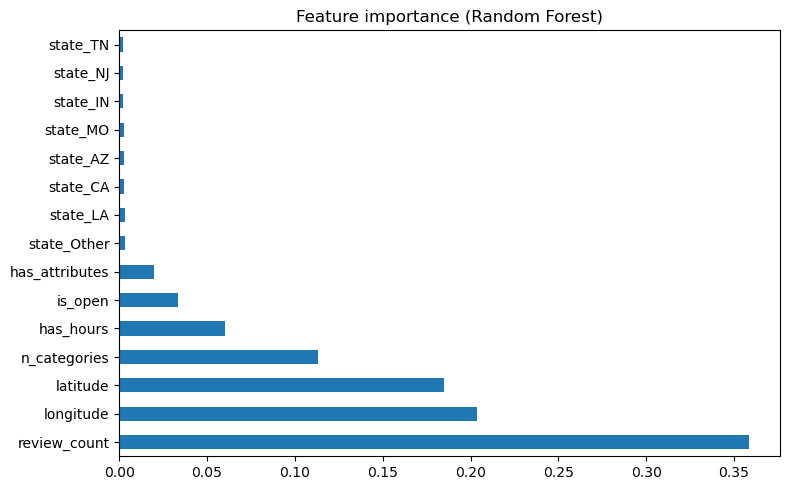

In [23]:
# 随机森林特征重要性（前 15）
import matplotlib.pyplot as plt
rf = models["RandomForest"]
imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
imp.head(15).plot(kind="barh", figsize=(8, 5), title="Feature importance (Random Forest)")
plt.tight_layout()
plt.show()